In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')
sys.path.insert(0, '../../../../../..')

# Decision labeling runtime models
import data_processing.decision_labeling
importlib.reload(data_processing.decision_labeling)
from data_processing.decision_labeling import DecisionLabeler

# Model
import suffix_pred.models.T_GAN_LSTM
importlib.reload(suffix_pred.models.T_GAN_LSTM)
from suffix_pred.models.T_GAN_LSTM import TaymouriAdversarialLSTM

# Decision-rule guided decoding and reasoning
import suffix_pred.decision_rule_guided_reasoning_inference
importlib.reload(suffix_pred.decision_rule_guided_reasoning_inference)
from suffix_pred.decision_rule_guided_reasoning_inference import DecisionGuidanceConfig, get_decision_guided_evaluator

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import evaluate_dls, dls_per_prefix_length, average_dls

In [2]:
# Model
# Model clean:
file_path_model = '../../../../../../models/BPIC20_DD/clean/BPIC20_DD_T_GAN_LSTM_v1_clean.pkl'

# Model decision_train:
# file_path_model = '../../../../../../models/BPIC20_DD/decision/BPIC20_DD_T_GAN_LSTM_v1_DA.pkl'

model = TaymouriAdversarialLSTM.load(file_path_model)

# Load the data: Use for eval always the clean test data:
file_path_test = '../../../../../../data/BPIC20_DD/tensor_data/normal/bpic20_dd_all_5_test.pkl'
test_dataset = torch.load(file_path_test, weights_only=False)

# Decision mining artifacts for runtime decision guidance
petri_net_path = '../../../../../../data/BPIC20_DD/Petri_net/bpic20_dd.pkl'
decision_bundle_path = '../../../../../../data/BPIC20_DD/Petri_net/data_aware_Petri_net/decision_places_bundle.json'
decision_model_dir = '../../../../../../data/BPIC20_DD/Petri_net/data_aware_Petri_net/models'

with open(petri_net_path, 'rb') as f:
    net, im, fm = pickle.load(f)

# Attributes must match decision model
dynamic_attributes = ["org:resource",
                          "amount",
                          "budget_status",
                          "revision_count",
                          "supplier_type",
                          "goods_match",
                          "invoice_deviation_pct",
                          "case_elapsed_time",
                          "event_elapsed_time"]

# Same across the whole trace
static_attributes = ["requester_seniority",
                      "department",
                      "category",
                      "priority"]

decision_labeler = DecisionLabeler(petri_net=(net, im, fm),
                                   decision_model_dir=decision_model_dir,
                                   decision_places_bundle_path=decision_bundle_path,
                                   dynamic_attributes=dynamic_attributes,
                                   static_attributes=static_attributes)

guidance_cfg = DecisionGuidanceConfig(epsilon=1e-3,
                                      beta_max=2.0,
                                      alpha=0.10,
                                      support_threshold=0.05)

print('Model and decision guidance artifacts loaded.')

Model and decision guidance artifacts loaded.


In [3]:
# Step 1: Guided decode suffixes (beam search with local decision reweighting)
beam_width = 3
mode = 'guided_beam'

guided_beam_eval = get_decision_guided_evaluator(kind='beam',
                                                 model=model,
                                                 dataset=test_dataset,
                                                 decision_labeler=decision_labeler,
                                                 guidance_config=guidance_cfg,
                                                 decision_places_bundle_path=decision_bundle_path,
                                                 concept_name='concept:name',
                                                 eos_value='EOS',
                                                 beam_width=beam_width)

guided_beam_outputs = []
guided_beam_reasoning = []

def _default_reasoning_row():
    return {'decision_steps': 0,
            'conflicts': 0,
            'conflict_rate': 0.0,
            'explained_steps': 0,
            'explained_rate': 0.0,
            'trace': []}

def _align_beam_reasonings(decoded_suffixes, reasonings):
    aligned = list(reasonings) if reasonings is not None else []
    needed = len(decoded_suffixes)
    while len(aligned) < needed:
        aligned.append(_default_reasoning_row())
    return aligned[:needed]

for case_id, prefix_len, prefix, target_suffix, decoded_suffixes, reasonings in guided_beam_eval.evaluate(random_order=False, return_reasoning=True):
    guided_beam_outputs.append({'case_id': case_id,
                                'prefix_len': int(prefix_len),
                                'prefix': prefix,
                                'target_suffix': target_suffix,
                                'decoded_suffixes': decoded_suffixes,
                                'mode': mode})

    beam_reasonings = _align_beam_reasonings(decoded_suffixes, reasonings)
    guided_beam_reasoning.append({'case_id': case_id,
                                  'prefix_len': int(prefix_len),
                                  'reasonings': beam_reasonings,
                                  # keep top beam alias for backward compatibility
                                  'reasoning': beam_reasonings[0] if len(beam_reasonings) > 0 else _default_reasoning_row()})

cache_outputs_path = '../../../../../../eval_results/BPIC20_DD/decision_decoding/bpic20_dd_t_gan_lstm_decision_guided_outputs.pkl'
cache_reasoning_path = '../../../../../../eval_results/BPIC20_DD/decision_decoding/bpic20_dd_t_gan_lstm_decision_guided_reasoning.pkl'

with open(cache_outputs_path, 'wb') as f:
    pickle.dump(guided_beam_outputs, f)

with open(cache_reasoning_path, 'wb') as f:
    pickle.dump(guided_beam_reasoning, f)

print(f"Decoded {len(guided_beam_outputs)} prefix rows in '{mode}'.")

# Step 2: Evaluate DLS from guided decoded outputs
guided_beam_df = evaluate_dls(guided_beam_outputs)
guided_beam_per_prefix = dls_per_prefix_length(guided_beam_df)
guided_beam_avg = average_dls(guided_beam_df)

# Step 3: Aggregate decision and explanation diagnostics across all beams
decision_steps = sum(rr.get('decision_steps', 0)
                    for row in guided_beam_reasoning
                    for rr in row.get('reasonings', []))
conflicts = sum(rr.get('conflicts', 0)
                for row in guided_beam_reasoning
                for rr in row.get('reasonings', []))
explained_steps = sum(rr.get('explained_steps', 0)
                      for row in guided_beam_reasoning
                      for rr in row.get('reasonings', []))

conflict_rate = (conflicts / decision_steps) if decision_steps > 0 else 0.0
explained_rate = (explained_steps / decision_steps) if decision_steps > 0 else 0.0

print(f"Average DLS ({mode}) on full test set: {guided_beam_avg:.4f}")
print(f"Decision steps: {decision_steps} | Conflicts: {conflicts} | Conflict rate: {conflict_rate:.4f}")
print(f"Explained steps: {explained_steps} | Explained rate: {explained_rate:.4f}")

  0%|          | 0/2100 [00:00<?, ?it/s]

Decoded 9124 prefix rows in 'guided_beam'.
Average DLS (guided_beam) on full test set: 0.8953
Decision steps: 166083 | Conflicts: 3362 | Conflict rate: 0.0202
Explained steps: 21590 | Explained rate: 0.1300


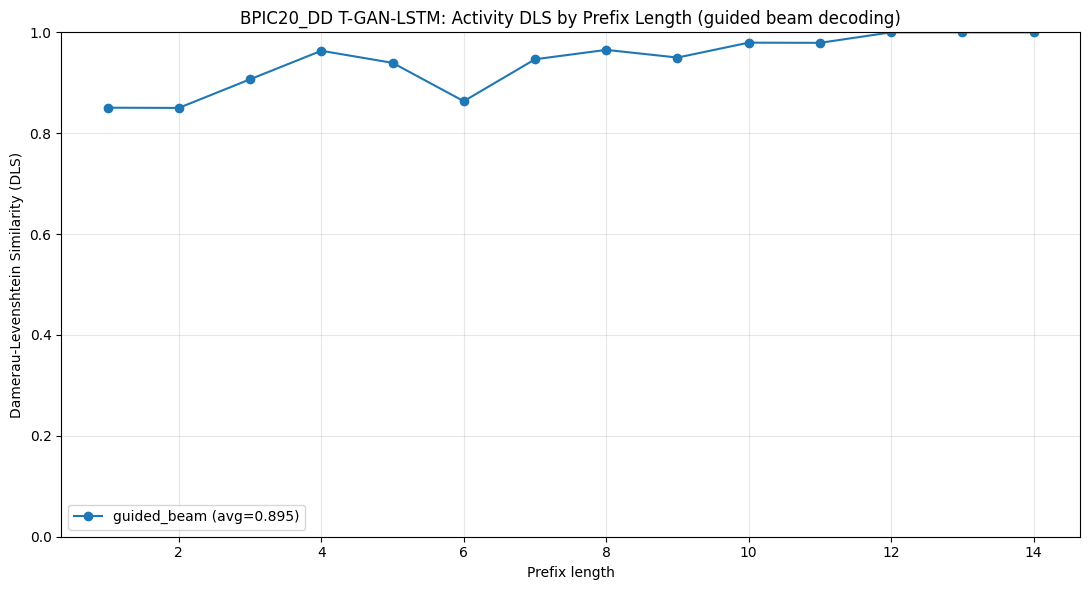

,mode,average_dls,decision_steps,conflicts,conflict_rate,explained_steps,explained_rate
0,guided_beam,0.895251,166083,3362,0.020243,21590,0.129995


In [4]:
# Plot DLS by prefix length for guided beam
plt.figure(figsize=(11, 6))

plt.plot(guided_beam_per_prefix['prefix_len'],
         guided_beam_per_prefix['dls'],
         marker='o',
         label=f"{mode} (avg={guided_beam_avg:.3f})")

plt.title('BPIC20_DD T-GAN-LSTM: Activity DLS by Prefix Length (guided beam decoding)')
plt.xlabel('Prefix length')
plt.ylabel('Damerau-Levenshtein Similarity (DLS)')
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'mode': [mode],
    'average_dls': [guided_beam_avg],
    'decision_steps': [decision_steps],
    'conflicts': [conflicts],
    'conflict_rate': [conflict_rate],
    'explained_steps': [explained_steps],
    'explained_rate': [explained_rate],
}).sort_values('average_dls', ascending=False).reset_index(drop=True)
summary

In [5]:
# Inspect guided predictions and rule-based reasoning examples with per-attribute checks
with open('../../../../../../eval_results/BPIC20_DD/decision_decoding/bpic20_dd_t_gan_lstm_decision_guided_outputs.pkl', 'rb') as f:
    cached_outputs = pickle.load(f)
    
with open('../../../../../../eval_results/BPIC20_DD/decision_decoding/bpic20_dd_t_gan_lstm_decision_guided_reasoning.pkl', 'rb') as f:
    cached_reasoning = pickle.load(f)

def _default_reasoning_row():
    return {'decision_steps': 0,
            'conflicts': 0,
            'conflict_rate': 0.0,
            'explained_steps': 0,
            'explained_rate': 0.0,
            'trace': []}

for i in range(min(100, len(cached_outputs))):
    row = cached_outputs[i]
    reason_row = cached_reasoning[i]

    beam_reasonings = reason_row.get('reasonings', [])
    if len(beam_reasonings) == 0 and reason_row.get('reasoning', None) is not None:
        # Backward compatibility with previous cache format.
        beam_reasonings = [reason_row['reasoning']]

    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:            {row['prefix']}")
    print(f"  Target suffix:     {row['target_suffix']}")
    decoded = row['decoded_suffixes']
    print(f"  Predicted beams:   {len(decoded)}")

    for b, beam in enumerate(decoded[:3]):
        reason = beam_reasonings[b] if b < len(beam_reasonings) else _default_reasoning_row()

        print(f"  Beam {b + 1}: {beam}")
        print(f"    Decision steps: {reason['decision_steps']} | Conflicts: {reason['conflicts']} | Conflict rate: {reason['conflict_rate']:.4f}")
        print(f"    Explained steps: {reason.get('explained_steps', 0)} | Explained rate: {reason.get('explained_rate', 0.0):.4f}")

        trace = reason.get('trace', [])
        if len(trace) == 0:
            print("    No supported rule-aligned reasoning step.")
            continue

        for step in trace[:3]:
            decision_top = step.get('decision_top_event')
            decision_top_prob = step.get('decision_top_prob')
            next_event = step['next_event']
            model_prob = step.get('model_prob')
            model_prob_str = f"{model_prob:.1%}" if model_prob is not None else "?"

            if decision_top is not None and decision_top != next_event:
                # Decision model's top pick differs from what the suffix predictor chose
                top_prob_str = f"p={decision_top_prob:.1%}" if decision_top_prob is not None else "p=?"
                print(f"    Decision step {step['step']}: {step['input_event']} -> "
                      f"{decision_top} ({top_prob_str}, decision top) at place {step['place']}, "
                      f"but with prob {model_prob_str} (model), {next_event} was predicted")
            else:
                top_prob_str = f", decision top p={decision_top_prob:.1%}" if decision_top_prob is not None else ""
                print(f"    Decision step {step['step']}: {step['input_event']} -> "
                      f"{next_event} (model prob: {model_prob_str}{top_prob_str}) at place {step['place']}")

            matched_rule = step.get('matched_rule')
            if matched_rule is not None:
                print(f"      Matched rule: {matched_rule.get('rule', '')}")

            attr_checks = step.get('attribute_checks', [])
            seen_attrs = set()
            if len(attr_checks) == 0:
                print("      No attribute checks available.")
            else:
                for chk in attr_checks:
                    attr_name = chk.get('attr', '')
                    attr_value = chk.get('value', None)
                    dedup_key = (attr_name, attr_value)
                    if dedup_key in seen_attrs:
                        continue
                    seen_attrs.add(dedup_key)
                    is_in_rule = bool(chk.get('in_rule_set', False))
                    print(f"      - {attr_name}: value={attr_value} | in_rule_set={is_in_rule}")
    print()

Case: declaration 100027  |  Prefix len: 1
  Prefix:            ['Declaration SUBMITTED']
  Target suffix:     ['Declaration APPROVED', 'Declaration FINAL_APPROVED', 'Request Payment', 'Payment Handled']
  Predicted beams:   3
  Beam 1: ['Declaration APPROVED', 'Declaration FINAL_APPROVED', 'Request Payment', 'Payment Handled']
    Decision steps: 4 | Conflicts: 0 | Conflict rate: 0.0000
    Explained steps: 1 | Explained rate: 0.2500
    Decision step 0: Declaration SUBMITTED -> Declaration REJECTED (p=64.4%, decision top) at place p_15, but with prob ? (model), Declaration APPROVED was predicted
      No attribute checks available.
    Decision step 1: Declaration APPROVED -> Declaration FINAL_APPROVED (model prob: ?, decision top p=60.5%) at place p_27
      No attribute checks available.
    Decision step 2: Declaration FINAL_APPROVED -> Request Payment (model prob: ?, decision top p=49.8%) at place p_22
      No attribute checks available.
  Beam 2: ['Declaration APPROVED', 'Decla